# 1. Imports and Setup

In [1]:
import sys
import os
from collections import defaultdict

# Add the src directory to sys.path
sys.path.append(os.path.abspath("../src"))

import torch
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, Markdown

from abstractions.dsl.abstraction import Abstraction
from abstractions.dsl.core import Shape
from abstractions.data.generator import generate_dataset
from abstractions.learning.utils import add, get_singletons, get_pairs
from abstractions.primitives.visualization import show_boxes, print_tree
from abstractions.learning.abstraction_discovery import find_abstractions, integrate_abstractions
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 2. Utility and Helper Functions

In [2]:
def count_nodes(shape):
    """Recursively counts the number of nodes in a shape program."""
    if not hasattr(shape, "param_tuple"):
        return 1
    _, args = shape.param_tuple()
    return 1 + sum(count_nodes(arg) for arg in args)

def contains_abstraction(shape):
    """Recursively checks if a shape program contains an Abstraction node."""
    if isinstance(shape, Abstraction):
        return True
    if not hasattr(shape, 'param_tuple'):
        return False
    _, args = shape.param_tuple()
    return any(contains_abstraction(arg) for arg in args)

def extract_float_params(param_list):
    """Extracts only float or integer parameters from a list of parameter tuples."""
    return [
        [p for p in tup if isinstance(p, (float, int))]
        for tup in param_list
    ]

def make_df_from_structure(param_list):
    """Converts a list of parameters into a Pandas DataFrame with float columns."""
    float_data = extract_float_params(param_list)
    float_data = [row for row in float_data if len(row) > 0]
    if not float_data:
        return pd.DataFrame()
    
    df = pd.DataFrame(float_data)
    df.columns = [f"param_{i}" for i in range(df.shape[1])]
    return df

# 3. Reusable Visualization Widgets

In [3]:
def visualize_dataset_interactive(dataset):
    """Creates an interactive slider to view shapes in a dataset."""
    output = widgets.Output()
    index_slider = widgets.IntSlider(
        value=0, min=0, max=len(dataset) - 1, step=1,
        description='Shape Index:', continuous_update=False
    )

    def update_display(change):
        idx = change["new"]
        output.clear_output()
        with output:
            shape = dataset[idx]
            display(Markdown(f"### Shape #{idx}"))
            print_tree(shape)
            show_boxes(shape.get_box_list(), backend="plotly")

    index_slider.observe(update_display, names="value")
    display(Markdown("### Visualize Dataset"), index_slider, output)
    update_display({"new": 0}) # Initial display

def create_structure_scatterplot_widget(structures, title):
    """Creates a dropdown to generate scatter plots for different structures."""
    plot_dropdown = widgets.Dropdown(
        options=list(structures.keys()),
        description="Structure:",
        layout=widgets.Layout(width="60%"),
    )
    plot_output = widgets.Output()

    def plot_on_change(change):
        structure_name = change["new"]
        plot_output.clear_output()
        with plot_output:
            param_list = structures[structure_name]
            df = make_df_from_structure(param_list)
            display(Markdown(f"### `{structure_name}` – {len(df)} instances"))
            if df.empty or df.shape[1] == 0:
                print("No float parameters to visualize.")
                return
            
            fig = px.scatter(
                df, x="param_0", y="param_1" if df.shape[1] > 1 else None,
                title=f"Scatterplot of parameters for {structure_name}",
                hover_data=df.columns
            ) if df.shape[1] > 1 else px.histogram(df, x="param_0", nbins=50, title=f"Histogram for {structure_name}")
            fig.show()

    plot_dropdown.observe(plot_on_change, names="value")
    display(Markdown(f"### {title}"), plot_dropdown, plot_output)
    if list(structures.keys()):
        plot_dropdown.value = list(structures.keys())[0]

def create_reconstruction_plot_widget(models, structures, threshold):
    """Creates a widget to visualize model reconstruction error."""
    dropdown = widgets.Dropdown(options=list(models.keys()), description="Structure:")
    output = widgets.Output()

    def update_plot(change):
        name = change["new"]
        output.clear_output()
        with output:
            model = models[name]
            param_list = structures[name]
            df = make_df_from_structure(param_list)
            if df.empty:
                print("No float parameters to plot.")
                return

            data = torch.tensor(df.values, dtype=torch.float32)
            model.eval()
            with torch.no_grad():
                _, recon = model(data)
                error = torch.max(torch.abs(recon - data), dim=1)[0]
                df["well_explained"] = error < threshold
            
            fig = px.scatter(
                df, x="param_0", y="param_1", color="well_explained",
                color_discrete_map={True: "green", False: "red"},
                title=f"{name} — Reconstruction Quality (Error < {threshold})"
            )
            fig.show()

    dropdown.observe(update_plot, names="value")
    display(Markdown("### Well-Defined Plots (Reconstruction Quality)"), dropdown, output)
    if list(models.keys()):
        update_plot({"new": dropdown.value})

def create_comparison_widget(original_dataset, abstracted_dataset):
    """Creates a widget to compare original and abstracted shapes."""
    num_before = sum(count_nodes(s) for s in original_dataset)
    num_after = sum(count_nodes(s) for s in abstracted_dataset)
    abstracted_indices = [i for i, s in enumerate(abstracted_dataset) if contains_abstraction(s)]
    
    summary = f"Total nodes reduced from {num_before} to {num_after}. "
    summary += f"{len(abstracted_indices)} / {len(original_dataset)} shapes were abstracted."
    display(Markdown(f"### Before and After Abstraction\n**Summary:** {summary}"))

    options = [
        (f"Index {i} | Δ={count_nodes(original_dataset[i]) - count_nodes(s)}", i)
        for i, s in enumerate(abstracted_dataset) if i in abstracted_indices
    ]
    if not options:
        print("No shapes were successfully abstracted.")
        return

    dropdown = widgets.Dropdown(options=options, description="Shape:")
    output = widgets.Output()

    def show_comparison(idx):
        output.clear_output()
        with output:
            before, after = original_dataset[idx], abstracted_dataset[idx]
            display(Markdown(f"#### Comparing Shape Index: {idx}"))
            print(f"Node Count: {count_nodes(before)} → {count_nodes(after)}")
            
            print("\nOriginal DSL Tree:")
            #print_tree(before)
            print(before)
            print("\nAbstracted DSL Tree:")
            #print_tree(after)
            print(after)
            
            display(Markdown("##### Original Geometry"))
            show_boxes(before.get_box_list(), backend="plotly")
            display(Markdown("##### Abstracted Geometry"))
            show_boxes(after.get_box_list(), backend="plotly")
            
    dropdown.observe(lambda change: show_comparison(change["new"]), names="value")
    display(dropdown, output)
    show_comparison(options[0][1])


# 4. Initial Abstraction

In [4]:
# 1.1. Generate and Visualize Dataset
print("--- PHASE 1: INITIAL ABSTRACTION ---")
dataset = (
    generate_dataset("chair_1", 1000) +
    generate_dataset("chair_2", 1000) +
    generate_dataset("chair_3", 1000)
)
visualize_dataset_interactive(dataset)

--- PHASE 1: INITIAL ABSTRACTION ---


### Visualize Dataset

IntSlider(value=0, continuous_update=False, description='Shape Index:', max=2999)

Output()

In [5]:
# 1.2. Generate Structures and Visualize Parameters
print("\nGenerating structures (singletons and pairs)...")
singletons = get_singletons(dataset)
pairs = get_pairs(dataset)
structures = add(singletons, pairs)
print(f"Found {len(structures)} unique structures.")
create_structure_scatterplot_widget(structures, "Initial Parameter Distribution")


Generating structures (singletons and pairs)...
Found 10 unique structures.


### Initial Parameter Distribution

Dropdown(description='Structure:', layout=Layout(width='60%'), options=('Union', 'Move', 'Rect', 'SymRef', 'Un…

Output()

### Move – 9000 instances

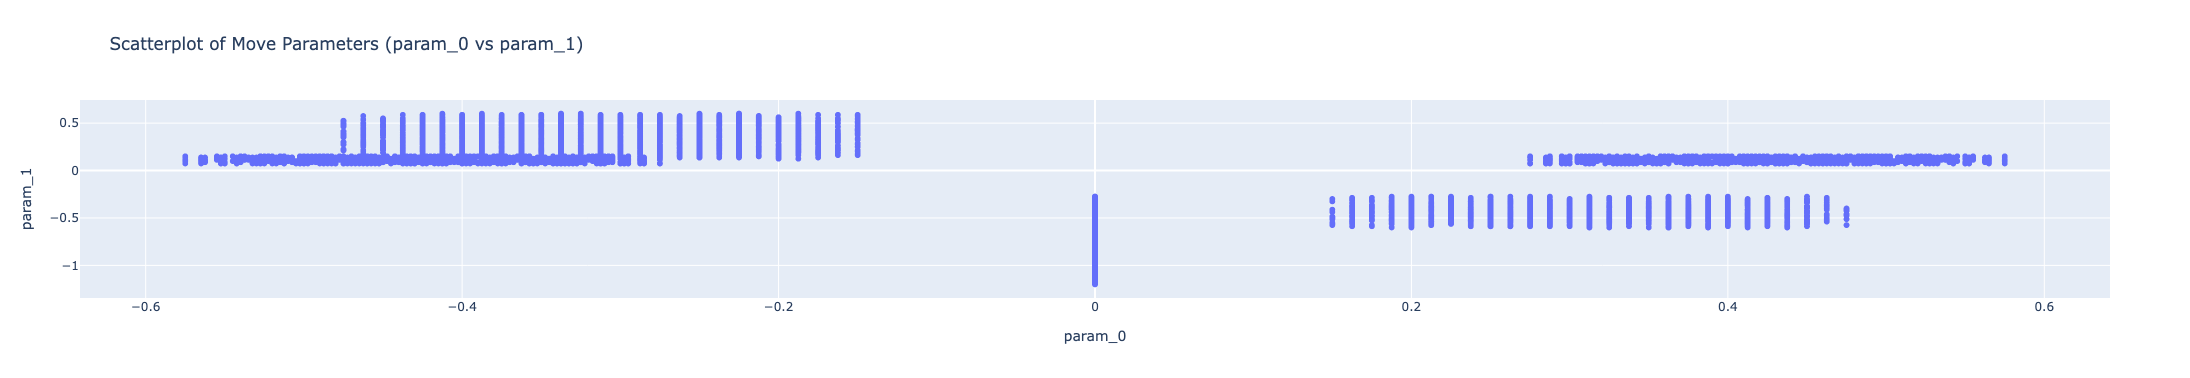

In [6]:
# Extract float-only params
def extract_float_params(param_list):
    return [
        [p for p in tup if isinstance(p, (float, int))]
        for tup in param_list
    ]

# Convert to DataFrame
move_params = structures["Move"]
float_data = extract_float_params(move_params)
float_data = [row for row in float_data if len(row) > 0]
df = pd.DataFrame(float_data)
df.columns = [f"param_{i}" for i in range(df.shape[1])]

# Display and plot
display(Markdown(f"### Move – {len(df)} instances"))

if df.shape[1] == 1:
    fig = px.histogram(df, x="param_0", nbins=50, title="Histogram of param_0 for Move")
else:
    fig = px.scatter(
        df, x="param_0", y="param_1",
        title="Scatterplot of Move Parameters (param_0 vs param_1)",
        hover_data=df.columns
    )
fig.show()

In [7]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

# Extract and prepare float params
move_params = structures["Move"]
float_data = [
    [p for p in tup if isinstance(p, (float, int))]
    for tup in move_params
]
float_data = [row for row in float_data if len(row) > 0]
df = pd.DataFrame(float_data)
df.columns = [f"param_{i}" for i in range(df.shape[1])]

# Normalize data for clustering
X_scaled = StandardScaler().fit_transform(df)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=0)
labels = kmeans.fit_predict(X_scaled)
df["cluster"] = labels

# Display and visualize
display(Markdown(f"### Move – {len(df)} instances – KMeans (k=4) Clusters"))

fig = px.scatter(
    df, x="param_0", y="param_1" if "param_1" in df.columns else "param_0",
    color="cluster",
    title="KMeans Clustering (k=4) of Move Parameters",
    hover_data=df.columns
)
fig.show()

### Move – 9000 instances – KMeans (k=4) Clusters

In [8]:
# Extract float parameters
move_params = structures["Move"]
float_data = [
    [p for p in tup if isinstance(p, (float, int))]
    for tup in move_params
]
float_data = [row for row in float_data if len(row) > 0]
df = pd.DataFrame(float_data)
df.columns = [f"param_{i}" for i in range(df.shape[1])]

# Standardize
X_scaled = StandardScaler().fit_transform(df)

# DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=10)
labels = dbscan.fit_predict(X_scaled)
df["cluster"] = labels

# Display results
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
display(Markdown(f"### Move – {len(df)} instances – DBSCAN Clusters"))
display(Markdown(f"**Clusters found:** {n_clusters} (Noise = {sum(labels == -1)})"))

# Plot
fig = px.scatter(
    df, x="param_0", y="param_1" if "param_1" in df.columns else "param_0",
    color="cluster",
    title="DBSCAN Clustering of Move Parameters",
    hover_data=df.columns,
    color_continuous_scale="Viridis"
)
fig.show()

### Move – 9000 instances – DBSCAN Clusters

**Clusters found:** 3 (Noise = 0)

### Move – 9000 instances – DBSCAN Clusters

**Clusters found:** 4 (Noise = 0)

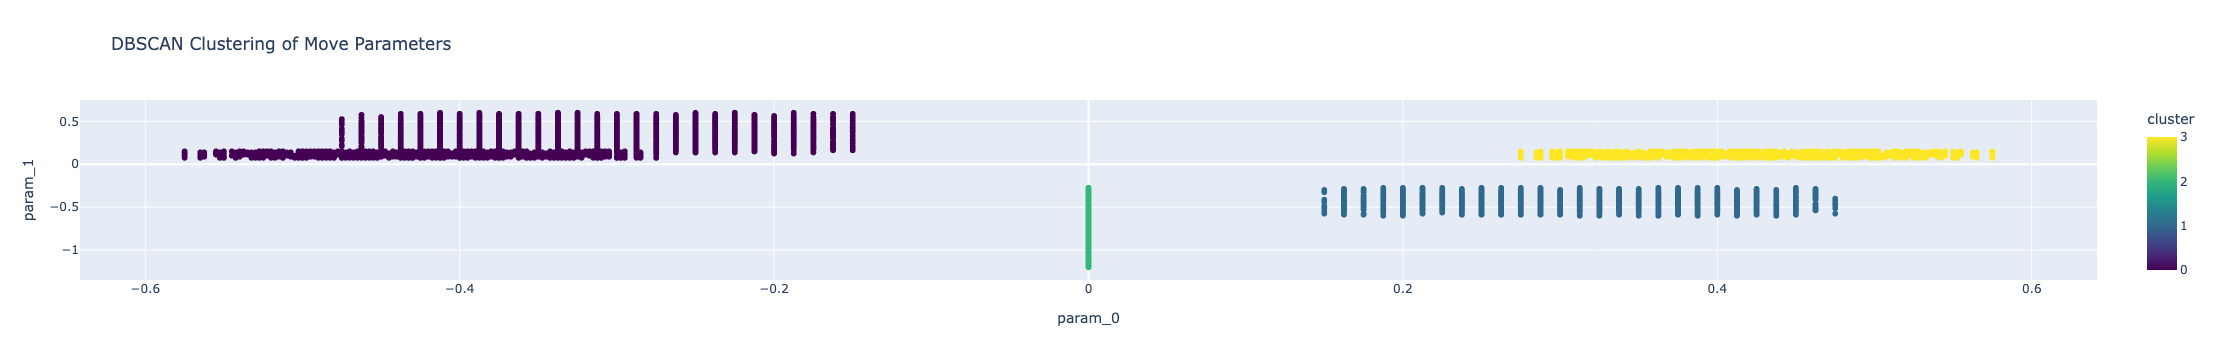

In [9]:
# Extract float parameters
move_params = structures["Move"]
float_data = [
    [p for p in tup if isinstance(p, (float, int))]
    for tup in move_params
]
float_data = [row for row in float_data if len(row) > 0]
df = pd.DataFrame(float_data)
df.columns = [f"param_{i}" for i in range(df.shape[1])]

# Standardize
X_scaled = StandardScaler().fit_transform(df)

# DBSCAN clustering
dbscan = DBSCAN(eps=0.2, min_samples=10)
labels = dbscan.fit_predict(X_scaled)
df["cluster"] = labels

# Display results
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
display(Markdown(f"### Move – {len(df)} instances – DBSCAN Clusters"))
display(Markdown(f"**Clusters found:** {n_clusters} (Noise = {sum(labels == -1)})"))

# Plot
fig = px.scatter(
    df, x="param_0", y="param_1" if "param_1" in df.columns else "param_0",
    color="cluster",
    title="DBSCAN Clustering of Move Parameters",
    hover_data=df.columns,
    color_continuous_scale="Viridis"
)
fig.show()

In [10]:
from sklearn.preprocessing import StandardScaler

# Filter float parameters
move_params = structures["Move"]
float_data = [tuple(p for p in t if isinstance(p, (float, int))) for t in move_params]
X = np.array(float_data)

# Normalize
X_scaled = StandardScaler().fit_transform(X)

In [11]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

def estimate_local_id(X, r1=0.3, r2=0.5):
    nbrs = NearestNeighbors(radius=r2).fit(X)
    distances, indices = nbrs.radius_neighbors(X, return_distance=True)

    ids = []
    for dist in distances:
        k2 = np.sum(dist < r2)
        k1 = np.sum(dist < r1)

        if k1 > 0 and k2 > k1:
            id_val = (np.log(k2) - np.log(k1)) / (np.log(r2) - np.log(r1))
        else:
            id_val = 0  # fallback for sparse area

        ids.append(id_val)

    return np.array(ids)

In [12]:
local_id = estimate_local_id(X_scaled, r1=0.1, r2=0.9)

In [13]:
from sklearn.cluster import DBSCAN

# Map ID to epsilon
epsilons = np.clip(0.2 + (local_id - np.min(local_id)) * 0.15, 0.6, 1.0)

# Custom DBSCAN: run separately for ID bands
labels = np.full(len(X_scaled), -1)
current_label = 0

for id_band in np.unique(np.round(local_id, 1)):
    band_indices = np.where(np.abs(local_id - id_band) < 0.1)[0]
    if len(band_indices) < 10:
        continue

    X_band = X_scaled[band_indices]
    eps = float(np.mean(epsilons[band_indices]))
    
    clustering = DBSCAN(eps=eps, min_samples=5).fit(X_band)
    band_labels = clustering.labels_

    for i, idx in enumerate(band_indices):
        if band_labels[i] != -1:
            labels[idx] = current_label + band_labels[i]

    current_label += (band_labels.max() + 1)

print(f"Found {len(set(labels)) - (1 if -1 in labels else 0)} clusters")

Found 56 clusters


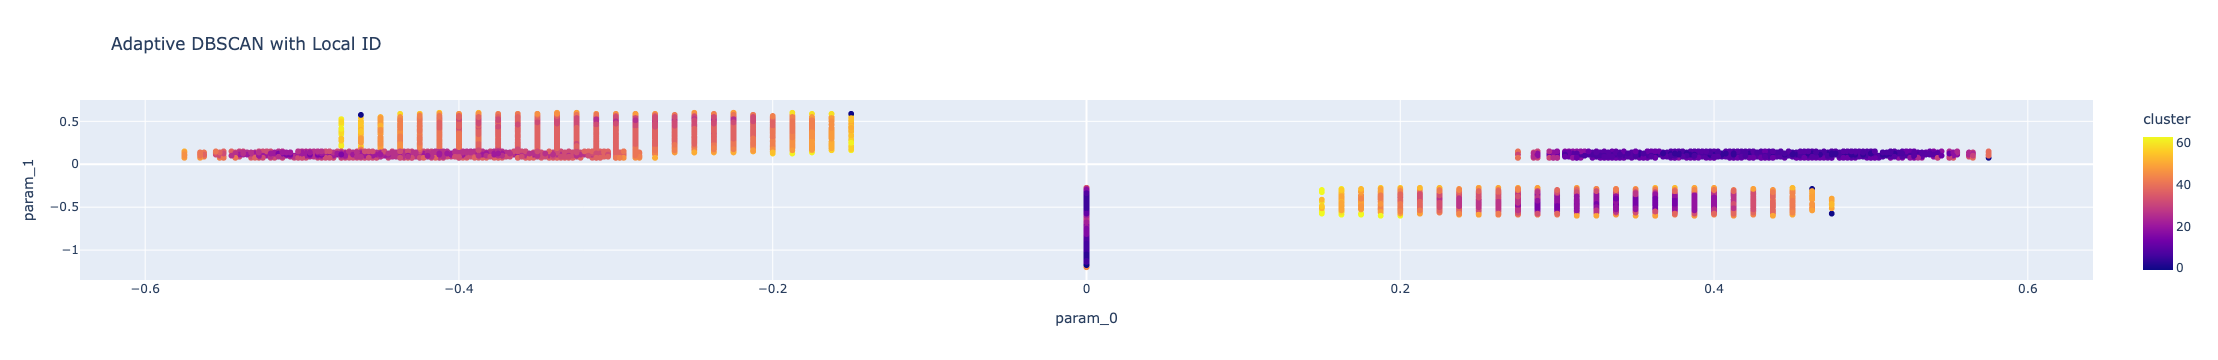

In [14]:
import plotly.express as px
df = pd.DataFrame(X, columns=["param_0", "param_1"])
df["ID"] = local_id
df["cluster"] = labels

fig = px.scatter(df, x="param_0", y="param_1", color="cluster",
                 hover_data=["ID"], title="Adaptive DBSCAN with Local ID")
fig.show()

In [15]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Extract float-only data
move_params = structures["Move"]
float_data = [tuple(p for p in t if isinstance(p, (float, int))) for t in move_params]
X = np.array(float_data)
X_scaled = StandardScaler().fit_transform(X)

In [16]:
from sklearn.neighbors import NearestNeighbors

def estimate_local_id(X, r1=0.3, r2=0.5):
    nbrs = NearestNeighbors(radius=r2).fit(X)
    distances, _ = nbrs.radius_neighbors(X, return_distance=True)

    ids = []
    for dist in distances:
        k2 = np.sum(dist < r2)
        k1 = np.sum(dist < r1)
        if k1 > 0 and k2 > k1:
            id_val = (np.log(k2) - np.log(k1)) / (np.log(r2) - np.log(r1))
        else:
            id_val = 0
        ids.append(id_val)

    return np.array(ids)

local_id = estimate_local_id(X_scaled)

In [17]:
import hdbscan

# You can filter low ID if desired
X_filtered = X_scaled[local_id > 0]

# Run HDBSCAN with minimum cluster size based on density
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric='euclidean'
).fit(X_filtered)

# Assign cluster labels to original points
labels = np.full(len(X_scaled), -1)
labels[local_id > 0] = clusterer.labels_

/opt/homebrew/Caskroom/miniconda/base/envs/abs/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/homebrew/Caskroom/miniconda/base/envs/abs/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



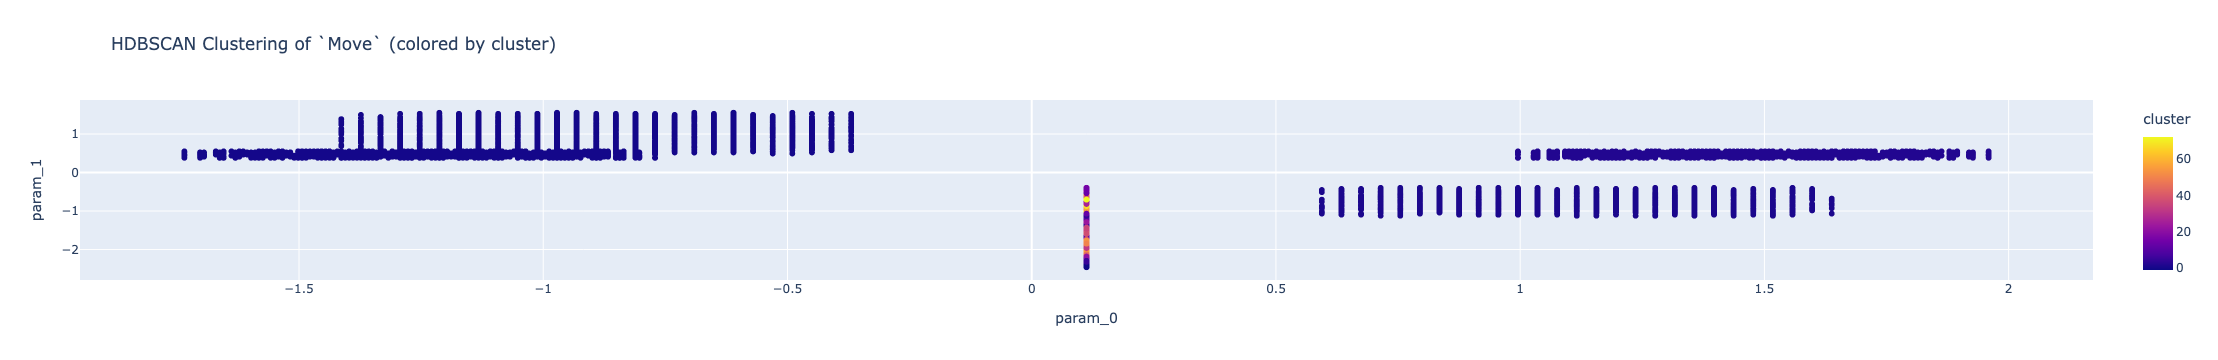

In [18]:
import pandas as pd
import plotly.express as px

df = pd.DataFrame(X_scaled, columns=["param_0", "param_1"])
df["local_id"] = local_id
df["cluster"] = labels

fig = px.scatter(df, x="param_0", y="param_1", color="cluster",
                 hover_data=["local_id"],
                 title="HDBSCAN Clustering of `Move` (colored by cluster)")
fig.show()

/opt/homebrew/Caskroom/miniconda/base/envs/abs/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/homebrew/Caskroom/miniconda/base/envs/abs/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



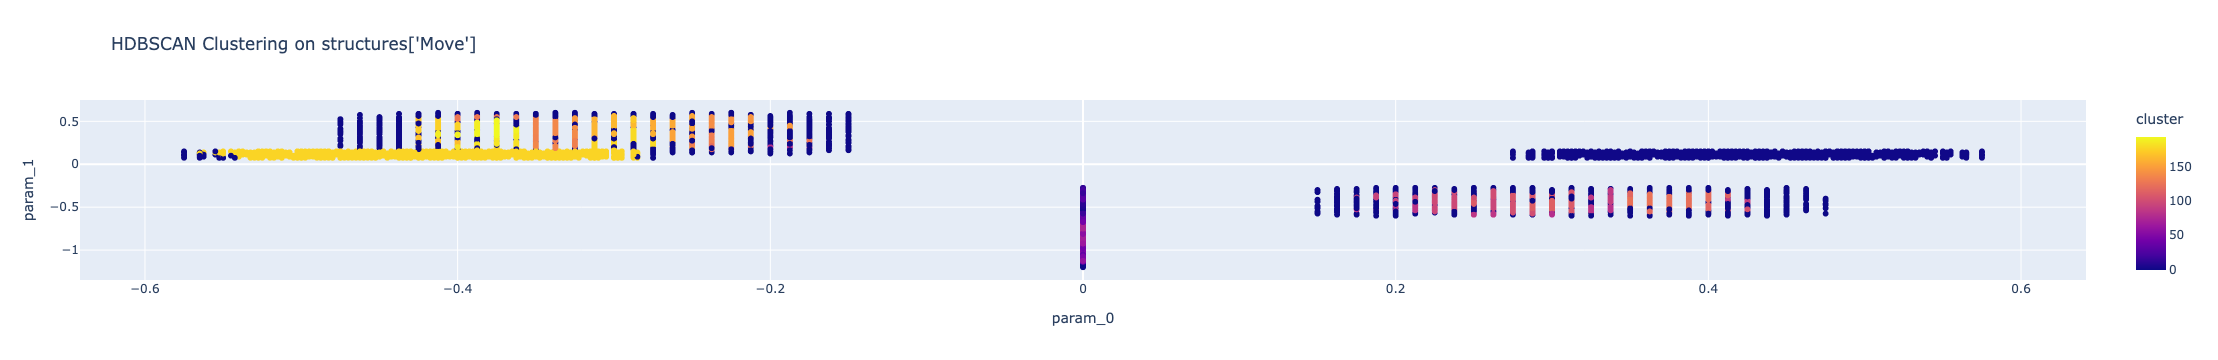

In [19]:
import numpy as np
import pandas as pd
import hdbscan
import plotly.express as px
from sklearn.preprocessing import StandardScaler

# --- Step 1: Extract float parameters from structures["Move"] ---
def extract_floats(param_list):
    return [
        [x for x in tup if isinstance(x, (float, int))]
        for tup in param_list
        if any(isinstance(x, (float, int)) for x in tup)
    ]

# --- Step 2: Prepare data ---
move_params = structures["Move"]
float_data = extract_floats(move_params)
df_move = pd.DataFrame(float_data, columns=[f"param_{i}" for i in range(len(float_data[0]))])

# --- Step 3: Normalize for clustering ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_move.values)

# --- Step 4: Run HDBSCAN clustering ---
clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
labels = clusterer.fit_predict(X_scaled)
df_move["cluster"] = labels

# --- Step 5: Visualize ---
fig = px.scatter(
    df_move,
    x="param_0",
    y="param_1" if "param_1" in df_move.columns else "param_0",
    color="cluster",
    title="HDBSCAN Clustering on structures['Move']",
    hover_data=df_move.columns,
)
fig.show()

/var/folders/zb/9bmh3s9s3q5_mlv24by4t5x00000gn/T/ipykernel_9918/2006238036.py:35: UserWarning:

Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)




Cluster: move_3 | 2046 samples

Cluster: move_0 | 3998 samples

Cluster: move_1 | 1954 samples

Cluster: move_2 | 1002 samples


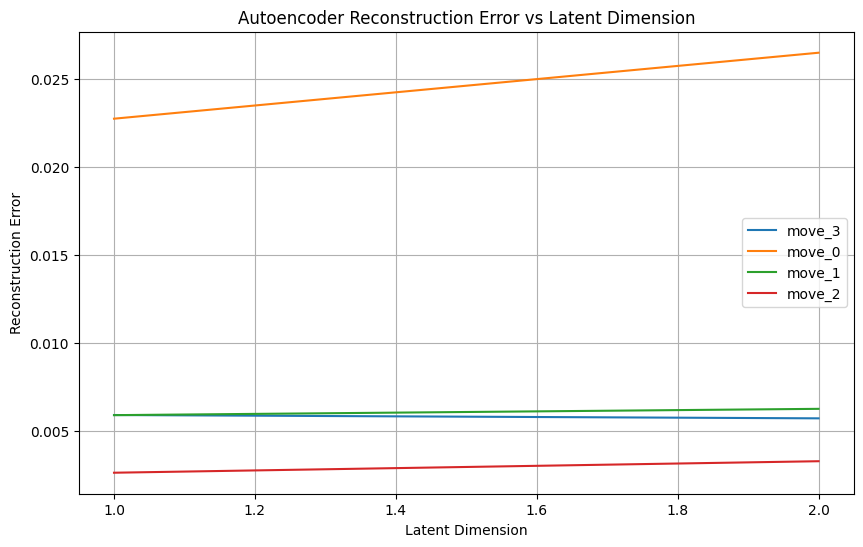

In [20]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from collections import defaultdict
from abstractions.learning.models import Autoencoder

# Helper: extract only float params
def extract_floats(params):
    return [tuple(p for p in t if isinstance(p, (float, int))) for t in params if any(isinstance(p, (float, int)) for p in t)]

# Parameters
structure_name = "Move"
float_params = extract_floats(structures[structure_name])
X = np.array(float_params)

# Cluster using KMeans
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(X)

# Clustered data dictionary
clustered = defaultdict(list)
for point, label in zip(X, labels):
    clustered[f"{structure_name.lower()}_{label}"].append(point)

# Sweep latent dimensions
latent_range = list(range(1, min(X.shape[1], 8) + 1))  # 1 to 8 or max dim
cluster_errors = {}

for key, param_list in clustered.items():
    print(f"\nCluster: {key} | {len(param_list)} samples")

    data = torch.tensor(param_list, dtype=torch.float32)
    errors_per_latent = []

    for latent_dim in latent_range:
        model = Autoencoder(input_dim=data.shape[1], hidden_dim=latent_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()

        # Simple training loop
        for _ in range(100):  # 100 epochs
            model.train()
            enc, recon = model(data)
            loss = loss_fn(recon, data)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            _, recon = model(data)
            error = torch.mean((recon - data) ** 2).item()
        errors_per_latent.append(error)

    cluster_errors[key] = errors_per_latent

# Plotting
plt.figure(figsize=(10, 6))
for key, errors in cluster_errors.items():
    plt.plot(latent_range, errors, label=key)
plt.xlabel("Latent Dimension")
plt.ylabel("Reconstruction Error")
plt.title("Autoencoder Reconstruction Error vs Latent Dimension")
plt.legend()
plt.grid(True)
plt.show()

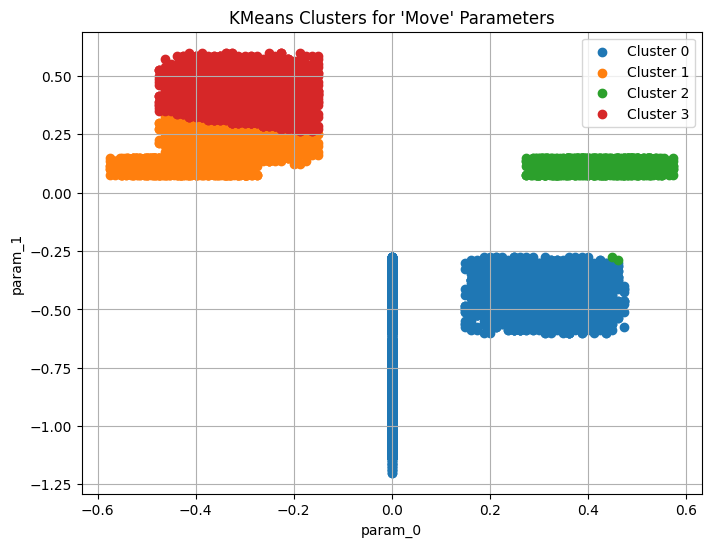


Cluster: move_3 | 2046 samples

Cluster: move_0 | 3998 samples

Cluster: move_1 | 1954 samples

Cluster: move_2 | 1002 samples


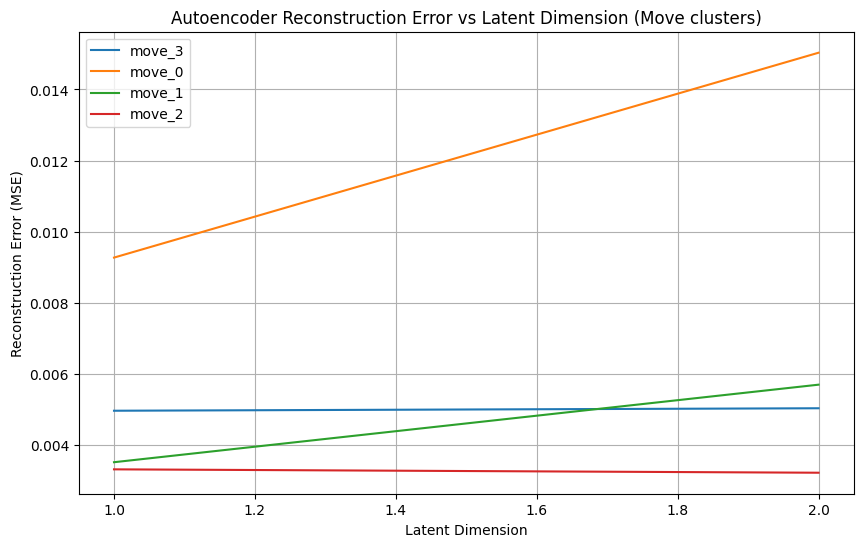

In [21]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from collections import defaultdict
from abstractions.learning.models import Autoencoder

# Helper: extract only float parameters from structure params
def extract_floats(params):
    return [
        tuple(p for p in t if isinstance(p, (float, int)))
        for t in params
        if any(isinstance(p, (float, int)) for p in t)
    ]

structure_name = "Move"  # Choose your structure here
float_params = extract_floats(structures[structure_name])
X = np.array(float_params)

# Cluster data using KMeans
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(X)

# Plot clusters
plt.figure(figsize=(8, 6))
for cluster_id in range(n_clusters):
    cluster_points = X[labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster_id}")
plt.title(f"KMeans Clusters for '{structure_name}' Parameters")
plt.xlabel("param_0")
plt.ylabel("param_1")
plt.legend()
plt.grid(True)
plt.show()

# Organize points by cluster label
clustered = defaultdict(list)
for point, label in zip(X, labels):
    clustered[f"{structure_name.lower()}_{label}"].append(point)

# Sweep latent dimensions and record reconstruction errors
latent_range = list(range(1, min(X.shape[1], 8) + 1))  # Sweep from 1 to 8 or max input dim
cluster_errors = {}

for key, param_list in clustered.items():
    print(f"\nCluster: {key} | {len(param_list)} samples")
    data = torch.tensor(param_list, dtype=torch.float32)
    errors_per_latent = []

    for latent_dim in latent_range:
        model = Autoencoder(input_dim=data.shape[1], hidden_dim=latent_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()

        # Training loop for 100 epochs
        for _ in range(100):
            model.train()
            enc, recon = model(data)
            loss = loss_fn(recon, data)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            _, recon = model(data)
            error = torch.mean((recon - data) ** 2).item()
        errors_per_latent.append(error)

    cluster_errors[key] = errors_per_latent

# Plot reconstruction errors vs latent dimension for each cluster
plt.figure(figsize=(10, 6))
for key, errors in cluster_errors.items():
    plt.plot(latent_range, errors, label=key)
plt.xlabel("Latent Dimension")
plt.ylabel("Reconstruction Error (MSE)")
plt.title(f"Autoencoder Reconstruction Error vs Latent Dimension ({structure_name} clusters)")
plt.legend()
plt.grid(True)
plt.show()

/var/folders/zb/9bmh3s9s3q5_mlv24by4t5x00000gn/T/ipykernel_9918/601167478.py:22: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



<Figure size 800x600 with 0 Axes>

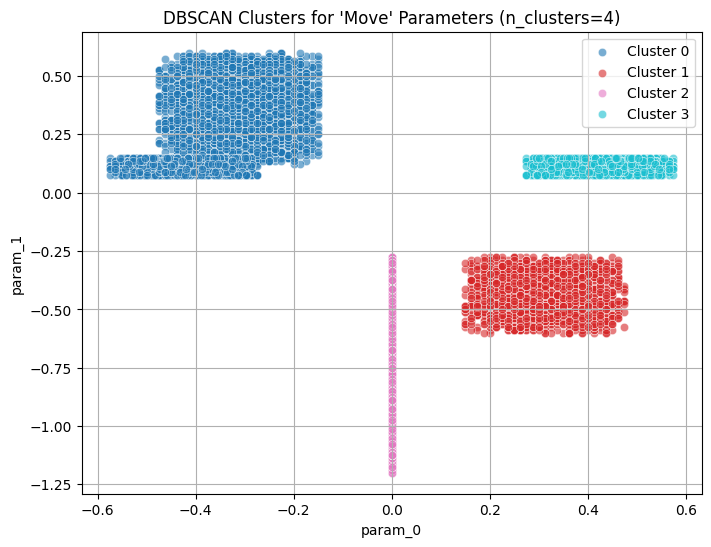


Cluster 0 | 4000 samples

Cluster 1 | 2000 samples

Cluster 2 | 2000 samples

Cluster 3 | 1000 samples


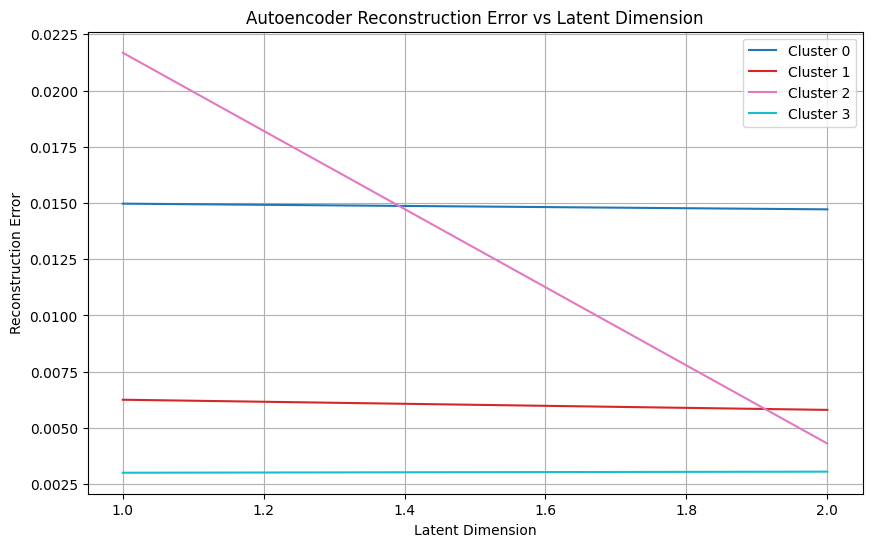

In [22]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from collections import defaultdict
from abstractions.learning.models import Autoencoder

# Parameters
structure_name = "Move"
float_params = [tuple(p for p in t if isinstance(p, (float, int))) for t in structures[structure_name] if any(isinstance(p, (float, int)) for p in t)]
X = np.array(float_params)

# DBSCAN clustering
dbscan = DBSCAN(eps=0.1, min_samples=10)
labels = dbscan.fit_predict(X)

unique_labels = sorted(set(labels))
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)

# Color map
cmap = plt.cm.get_cmap('tab10', n_clusters)
label_to_color = {}

plt.figure(figsize=(8, 6))
for idx, lbl in enumerate(unique_labels):
    if lbl == -1:
        label_to_color[lbl] = 'k'  # Noise is black
    else:
        label_to_color[lbl] = cmap(idx % n_clusters)

# Plot clusters with fixed colors
plt.figure(figsize=(8, 6))
for lbl in unique_labels:
    cluster_points = X[labels == lbl]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=[label_to_color[lbl]], label=f"Noise" if lbl == -1 else f"Cluster {lbl}", alpha=0.6, edgecolors='w', linewidth=0.5)
plt.title(f"DBSCAN Clusters for '{structure_name}' Parameters (n_clusters={n_clusters})")
plt.xlabel("param_0")
plt.ylabel("param_1")
plt.legend()
plt.grid(True)
plt.show()

# Group points per cluster for training
clustered = defaultdict(list)
for point, label in zip(X, labels):
    clustered[label].append(point)

latent_range = list(range(1, min(X.shape[1], 8) + 1))
cluster_errors = {}

# Train autoencoder per cluster and record errors
for lbl, points in clustered.items():
    if lbl == -1:
        print("Skipping noise cluster")
        continue
    print(f"\nCluster {lbl} | {len(points)} samples")
    data = torch.tensor(points, dtype=torch.float32)
    errors_per_latent = []

    for latent_dim in latent_range:
        model = Autoencoder(input_dim=data.shape[1], hidden_dim=latent_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()

        for _ in range(100):
            model.train()
            enc, recon = model(data)
            loss = loss_fn(recon, data)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            _, recon = model(data)
            error = torch.mean((recon - data) ** 2).item()
        errors_per_latent.append(error)
    cluster_errors[lbl] = errors_per_latent

# Plot reconstruction errors using same colors as clusters
plt.figure(figsize=(10, 6))
for lbl, errors in cluster_errors.items():
    plt.plot(latent_range, errors, label=f"Cluster {lbl}", color=label_to_color[lbl])
plt.xlabel("Latent Dimension")
plt.ylabel("Reconstruction Error")
plt.title("Autoencoder Reconstruction Error vs Latent Dimension")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# 1.3. Find Abstractions and Visualize Quality
print("\nFinding abstractions for structures...")
models, _ = find_abstractions(structures, retrain_iterations=1, error_threshold=0.01)
print(f"Trained models for {len(models)} structures.")
create_reconstruction_plot_widget(models, structures, threshold=0.01)


Finding abstractions for structures...
Iteration 1/1: training model for Move on 9000 structures.
Trained model for Move. Final train loss: 0.04515990984778032
Iteration 1/1: training model for Rect on 12000 structures.
Trained model for Rect. Final train loss: 0.0394340792195277
Iteration 1/1: training model for Union(Move, Rect) on 2000 structures.
Trained model for Union(Move, Rect). Final train loss: 0.04029519308824092
Iteration 1/1: training model for Union(Move, Move) on 2000 structures.
Trained model for Union(Move, Move). Final train loss: 0.0166461096087005
Iteration 1/1: training model for Union(Rect, Union) on 1000 structures.
Trained model for Union(Rect, Union). Final train loss: 0.03911496861837804
Iteration 1/1: training model for Union(Move, Union) on 1000 structures.
Trained model for Union(Move, Union). Final train loss: 0.05602894118055701
Trained models for 6 structures.


### Well-Defined Plots (Reconstruction Quality)

Dropdown(description='Structure:', options=('Move', 'Rect', 'Union(Move, Rect)', 'Union(Move, Move)', 'Union(R…

Output()

In [24]:
# 1.4. Apply Abstractions and Compare
print("\nApplying abstractions to dataset...")
abstracted_dataset_v1 = integrate_abstractions(dataset, models, error_threshold=0.03)
create_comparison_widget(dataset, abstracted_dataset_v1)


Applying abstractions to dataset...


### Before and After Abstraction
**Summary:** Total nodes reduced from 76000 to 52686. 2258 / 3000 shapes were abstracted.

Dropdown(description='Shape:', options=(('Index 0 | Δ=5', 0), ('Index 2 | Δ=5', 2), ('Index 3 | Δ=5', 3), ('In…

Output()

# 5. Abstraction after Clustering

In [25]:
print("\n--- PHASE 2: ABSTRACTION ON CLUSTERED STRUCTURES ---")

# 2.1. Cluster a list of specified structures
# Define which structures you want to attempt to cluster.
structure_names_to_cluster = ["Rect"] # CHANGED: Now a list
all_clustered_structures = {}

print(f"\nAttempting to cluster structures: {structure_names_to_cluster}...")

for structure_name in structure_names_to_cluster:
    print(f"\n--- Clustering '{structure_name}' ---")
    
    # Get the parameters for the current structure
    params = structures.get(structure_name)
    if not params:
        print(f"Structure '{structure_name}' not found or is empty. Skipping.")
        continue
        
    df = make_df_from_structure(params)

    if df.empty or df.shape[1] == 0:
        print(f"No float parameters to cluster for '{structure_name}'. Skipping.")
        continue

    # Normalize and cluster using DBSCAN
    X = StandardScaler().fit_transform(df.values)
    # Note: You might need to tune eps and min_samples for different structures
    labels = DBSCAN(eps=0.5, min_samples=10).fit_predict(X)
    df["cluster"] = labels
    
    # Visualize the clusters for the current structure
    num_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"Found {num_clusters_found} clusters for '{structure_name}'.")
    
    fig = px.scatter(
        df, 
        x="param_0", 
        y="param_1" if "param_1" in df.columns else None, 
        color="cluster",
        title=f"DBSCAN Clustering for '{structure_name}'"
    )
    fig.show()

    # Create new, more specific structures based on the clusters found
    cluster_map = defaultdict(list)
    for i, label in enumerate(labels):
        if label != -1:  # Ignore noise points
            # Create a unique name for the new clustered structure
            new_structure_name = f"{structure_name.lower()}_cluster_{label}"
            cluster_map[new_structure_name].append(params[i])
            
    # Add the newly found clusters to our collection
    all_clustered_structures.update(dict(cluster_map))


--- PHASE 2: ABSTRACTION ON CLUSTERED STRUCTURES ---

Attempting to cluster structures: ['Rect']...

--- Clustering 'Rect' ---
Found 2 clusters for 'Rect'.


In [26]:
# 2.2. Create Final Structure Set for Re-training
print("\n------------------------------------")
print(f"\nSaved a total of {len(all_clustered_structures)} new structures from clustering.")

# Start with all the new clustered structures
final_structures = all_clustered_structures.copy()

# Add back all original structures that were NOT targeted for clustering
for key, val in structures.items():
    if key not in structure_names_to_cluster:
        final_structures[key] = val
        
print(f"Created a new set of {len(final_structures)} total structures for re-training.")
print("Final structure keys:", list(final_structures.keys()))


------------------------------------

Saved a total of 2 new structures from clustering.
Created a new set of 11 total structures for re-training.
Final structure keys: ['rect_cluster_0', 'rect_cluster_1', 'Union', 'Move', 'SymRef', 'Union(Move, Rect)', 'Union(Union, SymRef)', 'Union(Move, Move)', 'Union(Union, Union)', 'Union(Rect, Union)', 'Union(Move, Union)']


In [27]:
# 2.3. Find Abstractions on Clustered Structures
print("\nFinding abstractions for the new clustered structures...")
# The rest of the script continues from here without changes
models_v2, _ = find_abstractions(final_structures, retrain_iterations=1, error_threshold=0.01)
print(f"Trained models for {len(models_v2)} new structures.")
create_reconstruction_plot_widget(models_v2, final_structures, threshold=0.01)


Finding abstractions for the new clustered structures...
Iteration 1/1: training model for rect_cluster_0 on 8000 structures.
Trained model for rect_cluster_0. Final train loss: 0.03758445766568184
Iteration 1/1: training model for rect_cluster_1 on 4000 structures.
Trained model for rect_cluster_1. Final train loss: 0.039492789064607924
Iteration 1/1: training model for Move on 9000 structures.
Trained model for Move. Final train loss: 0.046191182357411015
Iteration 1/1: training model for Union(Move, Rect) on 2000 structures.
Trained model for Union(Move, Rect). Final train loss: 0.040594028192572296
Iteration 1/1: training model for Union(Move, Move) on 2000 structures.
Trained model for Union(Move, Move). Final train loss: 0.009908710475428961
Iteration 1/1: training model for Union(Rect, Union) on 1000 structures.
Trained model for Union(Rect, Union). Final train loss: 0.039531649090349674
Iteration 1/1: training model for Union(Move, Union) on 1000 structures.
Trained model for 

### Well-Defined Plots (Reconstruction Quality)

Dropdown(description='Structure:', options=('rect_cluster_0', 'rect_cluster_1', 'Move', 'Union(Move, Rect)', '…

Output()

In [28]:
# 2.4. Apply New Abstractions and Compare
print("\nApplying new, clustered abstractions to the original dataset...")
abstracted_dataset_v2 = integrate_abstractions(dataset, models_v2, error_threshold=0.03)
create_comparison_widget(dataset, abstracted_dataset_v2)


Applying new, clustered abstractions to the original dataset...


### Before and After Abstraction
**Summary:** Total nodes reduced from 76000 to 52100. 2352 / 3000 shapes were abstracted.

Dropdown(description='Shape:', options=(('Index 0 | Δ=5', 0), ('Index 3 | Δ=5', 3), ('Index 4 | Δ=5', 4), ('In…

Output()

In [29]:
print("--- Dataset Comparison Summary ---")

# Calculate metrics for Original Dataset
original_total_nodes = sum(count_nodes(s) for s in dataset)
original_shapes_count = len(dataset)

print(f"\nOriginal Dataset (Initial State):")
print(f"  Total Nodes: {original_total_nodes}")
print(f"  Total Shapes: {original_shapes_count}")


# Calculate metrics for Phase 1 Abstracted Dataset
abstracted_v1_total_nodes = sum(count_nodes(s) for s in abstracted_dataset_v1)
abstracted_v1_shapes_abstracted_in_phase = sum(1 for s in abstracted_dataset_v1 if contains_abstraction(s))

print(f"\nAfter Phase 1: Base Primitive Abstractions:")
print(f"  Total Nodes: {abstracted_v1_total_nodes}")
print(f"  Nodes Reduced from Original: {original_total_nodes - abstracted_v1_total_nodes}")
print(f"  Shapes Abstracted in this Phase: {abstracted_v1_shapes_abstracted_in_phase} / {original_shapes_count}")


# Calculate metrics for Phase 2 Abstracted Dataset
abstracted_v2_total_nodes = sum(count_nodes(s) for s in abstracted_dataset_v2)
abstracted_v2_shapes_abstracted_in_phase = sum(1 for s in abstracted_dataset_v2 if contains_abstraction(s))

print(f"\nAfter Phase 2: Clustered Primitive Abstractions:")
print(f"  Total Nodes: {abstracted_v2_total_nodes}")
print(f"  Nodes Reduced from Phase 1: {abstracted_v1_total_nodes - abstracted_v2_total_nodes}")
print(f"  Shapes Abstracted in this Phase: {abstracted_v2_shapes_abstracted_in_phase} / {original_shapes_count}")

--- Dataset Comparison Summary ---

Original Dataset (Initial State):
  Total Nodes: 76000
  Total Shapes: 3000

After Phase 1: Base Primitive Abstractions:
  Total Nodes: 52686
  Nodes Reduced from Original: 23314
  Shapes Abstracted in this Phase: 2258 / 3000

After Phase 2: Clustered Primitive Abstractions:
  Total Nodes: 52100
  Nodes Reduced from Phase 1: 586
  Shapes Abstracted in this Phase: 2352 / 3000


In [30]:
dataset[0].get_box_list()

In [31]:
abstracted_dataset_v2[0]

In [32]:
import numpy as np
from abstractions.dsl.core import Shape
from abstractions.dsl.nodes import Union, Move, SymRef, SymTrans, Rect

def sample_shape_points(shape: Shape, num_points: int = 1000) -> np.ndarray:
    """
    Recursively samples 2D points from a DSL shape tree.

    Parameters
    ----------
    shape : Shape
        A shape program (root node).
    num_points : int
        Total number of points to sample.

    Returns
    -------
    np.ndarray
        Array of 2D sampled points of shape (N, 2).
    """
    if isinstance(shape, Union):
        left, right = shape.children
        n1 = num_points // 2
        n2 = num_points - n1
        return np.vstack([
            sample_shape_points(left, n1),
            sample_shape_points(right, n2)
        ])

    elif isinstance(shape, Move):
        child, dx, dy = shape.param_tuple()[1]
        pts = sample_shape_points(child, num_points)
        return pts + np.array([dx, dy])

    elif isinstance(shape, SymRef):
        child, axis = shape.param_tuple()[1]
        pts = sample_shape_points(child, num_points)
        if axis == "x":
            reflected = pts * np.array([-1, 1])
        elif axis == "y":
            reflected = pts * np.array([1, -1])
        else:
            raise ValueError(f"Unknown axis '{axis}'")
        return np.vstack([pts, reflected])

    elif isinstance(shape, SymTrans):
        child, axis, count, spacing = shape.param_tuple()[1]
        pts = sample_shape_points(child, max(num_points // count, 1))
        all_pts = []
        for i in range(count):
            offset = i * spacing
            dx, dy = (offset, 0) if axis == "x" else (0, offset)
            all_pts.append(pts + np.array([dx, dy]))
        return np.vstack(all_pts)

    elif isinstance(shape, Rect):
        width, height = shape.param_tuple()[1]
        x = np.random.uniform(-width / 2, width / 2, num_points)
        y = np.random.uniform(-height / 2, height / 2, num_points)
        return np.stack([x, y], axis=1)

    else:
        # Unknown shape node; return no points
        return np.zeros((0, 2))

In [33]:
from scipy.spatial.distance import cdist

def shape_sampling_error(shape1, shape2, num_points=1000):
    p1 = sample_shape_points(shape1, num_points)
    p2 = sample_shape_points(shape2, num_points)

    d12 = cdist(p1, p2).min(axis=1)
    d21 = cdist(p2, p1).min(axis=1)
    return (d12.mean() + d21.mean()) / 2

In [34]:
idx = 0
original = dataset[idx]
abstracted = abstracted_dataset_v2[idx]
print("Sampling-based error:", shape_sampling_error(original, abstracted))

Sampling-based error: 0.04447303152119095


In [35]:
def create_sampling_error_comparison(original_dataset, abstracted_dataset):
    num_before = sum(count_nodes(s) for s in original_dataset)
    num_after = sum(count_nodes(s) for s in abstracted_dataset)
    abstracted_indices = [i for i, s in enumerate(abstracted_dataset) if contains_abstraction(s)]
    
    summary = f"Total nodes reduced from {num_before} to {num_after}. "
    summary += f"{len(abstracted_indices)} / {len(original_dataset)} shapes were abstracted."
    display(Markdown(f"### Before and After Abstraction\n**Summary:** {summary}"))

    options = [
        (f"Index {i} | Δ={count_nodes(original_dataset[i]) - count_nodes(s)}", i)
        for i, s in enumerate(abstracted_dataset) if i in abstracted_indices
    ]
    if not options:
        print("No abstracted shapes found.")
        return

    dropdown = widgets.Dropdown(options=options, description="Shape:")
    output = widgets.Output()

    def show_comparison(idx):
        output.clear_output()
        with output:
            before, after = original_dataset[idx], abstracted_dataset[idx]
            display(Markdown(f"#### Shape Index: {idx}"))
            print(f"Node Count: {count_nodes(before)} → {count_nodes(after)}")

            err = shape_sampling_error(before, after)
            print(f"\nSampling-based Chamfer Distance: {err:.4f}")

            print("\nOriginal DSL Tree:")
            print(before)
            print("\nAbstracted DSL Tree:")
            print(after)

            display(Markdown("##### Geometry Comparison"))
            show_boxes(before.get_box_list(), backend="plotly")
            show_boxes(after.get_box_list(), backend="plotly")

    dropdown.observe(lambda change: show_comparison(change["new"]), names="value")
    display(dropdown, output)
    show_comparison(options[0][1])

In [36]:
create_sampling_error_comparison(dataset, abstracted_dataset_v2)

### Before and After Abstraction
**Summary:** Total nodes reduced from 76000 to 52100. 2352 / 3000 shapes were abstracted.

Dropdown(description='Shape:', options=(('Index 0 | Δ=5', 0), ('Index 3 | Δ=5', 3), ('Index 4 | Δ=5', 4), ('In…

Output()

In [37]:
import plotly.express as px
import numpy as np

def plot_sampled_points(shape, num_points=1000):
    """
    Samples points from a shape and visualizes them using Plotly.

    Parameters
    ----------
    shape : Shape
        The shape object to sample.
    num_points : int
        Number of points to sample.

    Returns
    -------
    None
    """
    points = sample_shape_points(shape, num_points)
    
    if points.shape[0] == 0:
        print("No points sampled.")
        return

    fig = px.scatter(
        x=points[:, 0], y=points[:, 1],
        title="Sampled Points from Shape",
        labels={"x": "X", "y": "Y"},
    )
    fig.update_layout(
        yaxis=dict(scaleanchor="x", scaleratio=1),
        showlegend=False
    )
    fig.show()

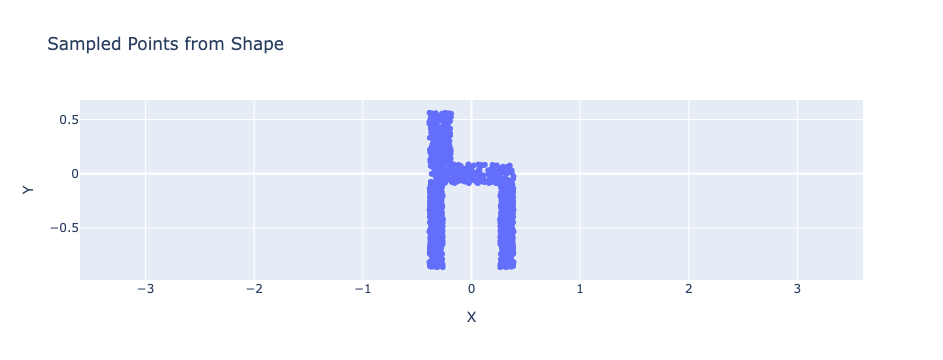

In [38]:
plot_sampled_points(dataset[405], num_points=1000)

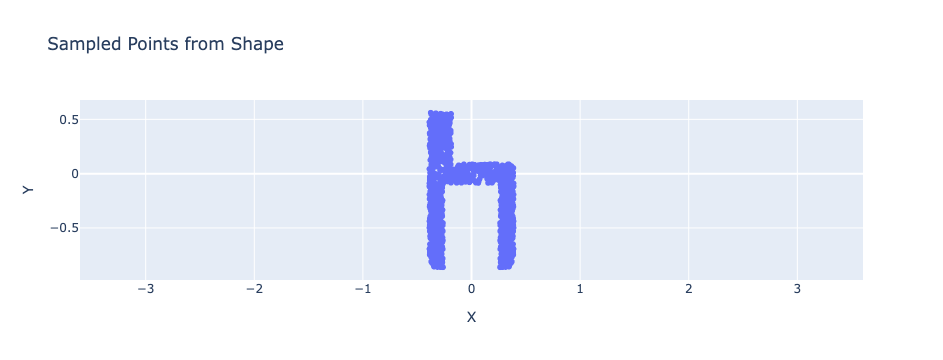

In [39]:
plot_sampled_points(abstracted_dataset_v2[405], num_points=1000)